In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
from datetime import date
from sklearn.metrics import root_mean_squared_error

from aquacrop import AquaCrop, Crop, Soil, Weather, InitialConditions
from aquacrop.templates import manuloa_co2_records

from aquacrop_slovenia import config
from aquacrop_slovenia.prepare_weather import load_station_weather
from aquacrop_slovenia.parameter_defaults_jablje import jablje_soil_layers, jablje_curve_number, jablje_readily_evaporable_water, jablje_maize_params
from aquacrop_slovenia.management_defaults import optimal_management
from aquacrop_slovenia.intial_conditions_defaults import intial_cond_params
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison

In [20]:
# Set up working directory for outputs
output_dir = config.MODELS_DIR / "testing"

plant and end dates are set to be the same every year - TODO TEMPORARY!!!

We exclude 2017 since we dont have ET data for most of the year

In [21]:
#year = 1993
simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 10, 10), # TODO temporary
        "planting_date": date(year, 5, 3), # TODO temporary
        "is_seeding_year": True,
    }
#]
for year in range(1993, 2024) if year != 2017]

In [22]:
jablje_temperatures, jablje_eto, jablje_rain = load_station_weather(8) # Jablje uses ARSO meteo station 8 data

In [23]:
jablje_weather = Weather(
    location="Jablje",
    temperatures=jablje_temperatures,
    eto_values=jablje_eto,
    rainfall_values=jablje_rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=manuloa_co2_records
)

In [24]:
jablje_maize = Crop(
    name="Jablje Maize",
    description="Jablje maize uncalibrated",
    params=jablje_maize_params
)

In [25]:
jablje_soil = Soil(
    name="Jablje Soil",
    description="Jablje silt loam soil uncalibrated",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water
)

In [26]:
default_initial_conditions = InitialConditions(
    name="DefaultInitialConditions",
    description="Default initial conditions with AquaCrop calculated defaults",
    params=intial_cond_params
)

In [27]:
# Create AquaCrop simulation
simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=jablje_maize,
    soil=jablje_soil,
    management=optimal_management,
    initial_conditions=default_initial_conditions,
    climate=jablje_weather,
    working_dir=output_dir,
    need_daily_output=True,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False
)

In [28]:
# Run the simulation
results = simulation.run()

Setting up working directory at: /Users/rokuk/Documents/Code.nosync/Python/aquacrop-slovenia/models/testing
Running AquaCrop simulation with project file: /Users/rokuk/Documents/Code.nosync/Python/aquacrop-slovenia/models/testing/LIST/PROJECT.PRM
Detected platform: darwin (arm64)
Looking for executable at: /Users/rokuk/Documents/Code.nosync/Python/aquacrop-slovenia/.venv/lib/python3.14/site-packages/model/macOS/aquacrop
Using AquaCrop executable: /Users/rokuk/Documents/Code.nosync/Python/aquacrop-slovenia/models/testing/aquacrop
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [29]:
results["season"]

,RunNr,Day1,Month1,Year1,Rain,ETo,GD,CO2,Irri,Infilt,...,HI,Y(dry),Y(fresh),WPet,Bin,Bout,DayN,MonthN,YearN,Project
0,1,1,1,1993,765.3,723.8,1099.9,357.21,0.0,667.0,...,37.8,7.770,8.633,2.45,0.0,0.0,10,10,1993,PROJECT.PRM
1,2,1,1,1994,1019.4,706.5,1203.3,358.96,0.0,909.6,...,43.4,10.489,11.655,2.70,0.0,0.0,10,10,1994,PROJECT.PRM
2,3,1,1,1995,1199.6,647.7,989.3,360.97,0.0,986.2,...,43.4,8.819,9.799,2.79,0.0,0.0,10,10,1995,PROJECT.PRM
3,4,1,1,1996,1087.0,603.8,965.7,362.74,0.0,887.7,...,37.3,7.351,8.168,2.35,0.0,0.0,10,10,1996,PROJECT.PRM
4,5,1,1,1997,740.0,683.6,1095.2,363.88,0.0,664.4,...,42.6,9.795,10.883,2.89,0.0,0.0,10,10,1997,PROJECT.PRM
5,6,1,1,1998,1068.3,671.4,1180.7,366.84,0.0,907.9,...,37.4,8.889,9.877,2.65,0.0,0.0,10,10,1998,PROJECT.PRM
6,7,1,1,1999,1089.3,642.0,1192.4,368.54,0.0,924.0,...,43.4,9.819,10.910,2.85,0.0,0.0,10,10,1999,PROJECT.PRM
7,8,1,1,2000,869.7,704.3,1172.3,369.71,0.0,779.4,...,33.7,7.165,7.961,1.98,0.0,0.0,10,10,2000,PROJECT.PRM
8,9,1,1,2001,1054.2,661.7,1127.3,371.32,0.0,896.4,...,43.4,9.952,11.058,2.78,0.0,0.0,10,10,2001,PROJECT.PRM
9,10,1,1,2002,865.7,643.0,1132.7,373.45,0.0,778.1,...,43.4,10.614,11.793,2.91,0.0,0.0,10,10,2002,PROJECT.PRM


<Axes: xlabel='Year1'>

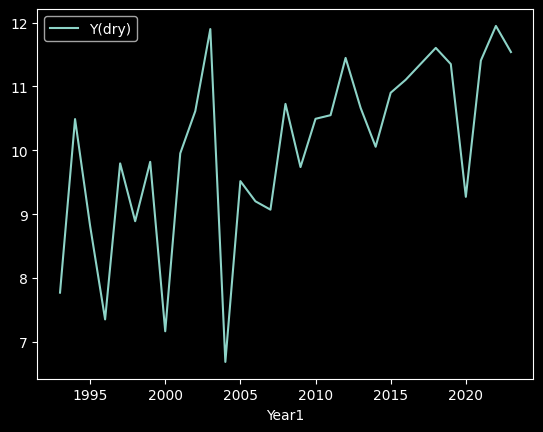

In [30]:
results["season"].plot(x="Year1", y="Y(dry)")

In [31]:
get_yield("jablje", "A", "N0")

,year,yield
0,1993,6.163
1,1994,5.558
2,1995,6.702
3,1996,2.884
4,1997,4.139
5,1998,2.967
6,1999,2.547
7,2000,3.405
8,2001,2.394
9,2002,5.041


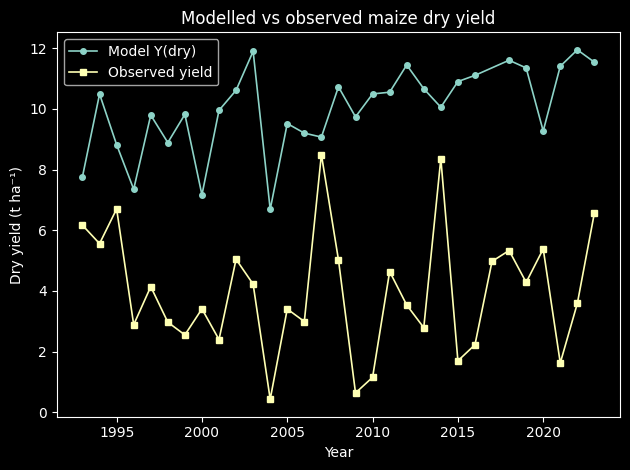

In [32]:
plot_yield_timeseries_comparison(results["season"][["Year1", "Y(dry)"]], get_yield("jablje", "A", "N0"))

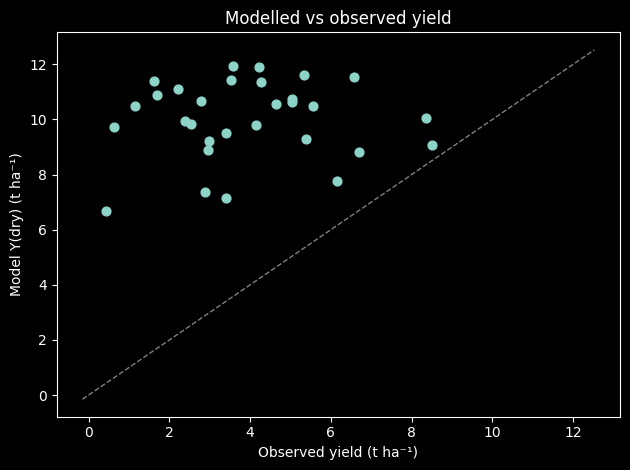

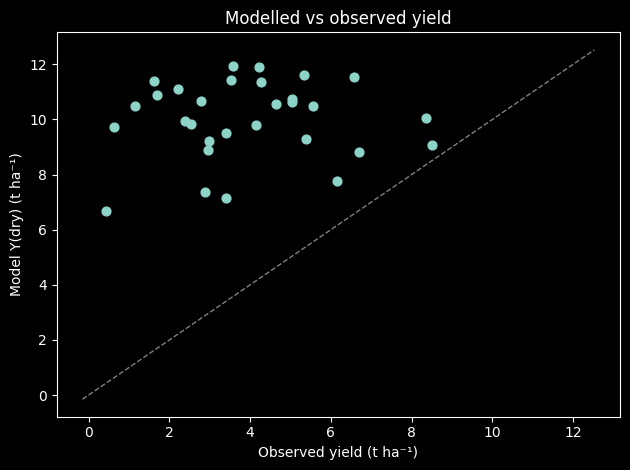

In [33]:
plot_yield_scatter(results["season"][["Year1", "Y(dry)"]], get_yield("jablje", "A", "N0"))

In [34]:
root_mean_squared_error(get_yield_for_comparison("jablje", "A", "N0"), results["season"][["Year1", "Y(dry)"]])

3.2553808494552525

In [ ]:
results["day"]

In [ ]:
results["day"].plot(y="Biomass")

In [ ]:
results["day"].plot(y="CC")

In [ ]:
results["day"].plot(y="Tr")

In [ ]:
results["day"].plot(y="Y(dry)")

In [ ]:
from aquacrop_slovenia.diagnostics import compute_annual_gdd

base_temp = maize_params['base_temp']
upper_temp = maize_params['upper_temp']

gdd_by_year = compute_annual_gdd(8, base_temp, upper_temp)
gdd_by_year

In [ ]:
from aquacrop_slovenia.diagnostics import plot_gdd_and_yield

plot_gdd_and_yield(gdd_by_year, results["season"], title="Annual GDD and Maize Dry Yield — Jablje")